In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
import platform
from matplotlib import rc

plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('Linux system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

Linux system... font set to NanumGothic


## 우리동네 인구 분석
- 2020년 ~ 2025년 연령별 인구 현황과 주민등록 인구 및 세대 현황 데이터 이용

In [3]:
df_age = pd.read_csv('data/연령별인구현황.csv', encoding='cp949')

In [4]:
df_age.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Columns: 235 entries, 행정구역 to 2025년_여_100세 이상
dtypes: int64(23), str(212)
memory usage: 35.0 KB


In [5]:
df_age.describe()

,2020년_계_100세 이상,2020년_남_90~99세,2020년_남_100세 이상,2020년_여_100세 이상,2021년_계_100세 이상,2021년_남_90~99세,2021년_남_100세 이상,2021년_여_100세 이상,2022년_계_100세 이상,2022년_남_90~99세,...,2023년_남_90~99세,2023년_남_100세 이상,2023년_여_100세 이상,2024년_계_100세 이상,2024년_남_90~99세,2024년_남_100세 이상,2024년_여_100세 이상,2025년_계_100세 이상,2025년_남_100세 이상,2025년_여_100세 이상
count,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,...,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,23.473684,63.894737,6.210526,17.263158,12.000000,71.789474,2.210526,9.789474,12.947368,76.105263,...,81.578947,2.526316,10.842105,12.631579,96.631579,2.842105,9.789474,11.789474,2.631579,9.157895
std,49.139674,133.718151,13.053645,36.201354,25.203615,150.211177,4.779342,20.525266,27.035930,158.719492,...,170.095828,5.357948,22.586287,26.310561,201.684630,6.085166,20.427593,24.523410,5.589778,19.050410
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,...,7.000000,0.000000,1.000000,1.000000,6.000000,0.000000,1.000000,2.000000,0.000000,1.000000
25%,6.000000,21.500000,1.000000,4.000000,2.000000,21.000000,0.000000,2.000000,3.000000,24.000000,...,28.500000,0.500000,3.000000,4.000000,31.500000,0.500000,3.000000,3.000000,0.000000,3.000000
50%,13.000000,30.000000,3.000000,10.000000,7.000000,33.000000,1.000000,6.000000,7.000000,32.000000,...,35.000000,1.000000,5.000000,6.000000,38.000000,1.000000,5.000000,6.000000,1.000000,4.000000
75%,16.000000,44.000000,5.000000,13.000000,10.000000,47.500000,2.000000,8.000000,9.000000,55.500000,...,59.500000,2.000000,7.500000,11.500000,74.500000,2.500000,8.000000,9.500000,2.500000,8.000000
max,223.000000,607.000000,59.000000,164.000000,114.000000,682.000000,21.000000,93.000000,123.000000,723.000000,...,775.000000,24.000000,103.000000,120.000000,918.000000,27.000000,93.000000,112.000000,25.000000,87.000000


In [6]:
df_age.shape

(19, 235)

In [7]:
df_pop= pd.read_csv('data/주민등록인구및세대현황.csv', encoding='cp949')

In [8]:
df_pop.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 37 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   행정구역          19 non-null     str    
 1   2020년_총인구수    19 non-null     str    
 2   2020년_세대수     19 non-null     str    
 3   2020년_세대당 인구  19 non-null     float64
 4   2020년_남자 인구수  19 non-null     str    
 5   2020년_여자 인구수  19 non-null     str    
 6   2020년_남여 비율   19 non-null     float64
 7   2021년_총인구수    18 non-null     str    
 8   2021년_세대수     18 non-null     str    
 9   2021년_세대당 인구  18 non-null     float64
 10  2021년_남자 인구수  18 non-null     str    
 11  2021년_여자 인구수  18 non-null     str    
 12  2021년_남여 비율   18 non-null     float64
 13  2022년_총인구수    19 non-null     str    
 14  2022년_세대수     19 non-null     str    
 15  2022년_세대당 인구  19 non-null     float64
 16  2022년_남자 인구수  19 non-null     str    
 17  2022년_여자 인구수  19 non-null     str    
 18  2022년_남여 비율   19 non-null     float64
 19  

In [9]:
df_pop.describe()

,2020년_세대당 인구,2020년_남여 비율,2021년_세대당 인구,2021년_남여 비율,2022년_세대당 인구,2022년_남여 비율,2023년_세대당 인구,2023년_남여 비율,2024년_세대당 인구,2024년_남여 비율,2025년_세대당 인구,2025년_남여 비율
count,19.000000,19.000000,18.000000,18.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,2.263684,0.968947,2.344444,1.023333,2.322632,1.023684,2.296316,1.025263,2.277895,1.021579,2.255789,1.019474
std,0.612764,0.248079,0.279752,0.091844,0.269234,0.095871,0.275726,0.117112,0.270320,0.111319,0.268914,0.114817
min,0.000000,0.000000,1.720000,0.950000,1.690000,0.940000,1.630000,0.940000,1.640000,0.940000,1.640000,0.940000
25%,2.160000,0.970000,2.192500,0.970000,2.195000,0.970000,2.180000,0.965000,2.160000,0.960000,2.130000,0.960000
50%,2.450000,1.000000,2.405000,1.000000,2.390000,1.000000,2.360000,1.000000,2.340000,1.000000,2.320000,1.000000
75%,2.575000,1.035000,2.565000,1.042500,2.530000,1.030000,2.510000,1.030000,2.480000,1.025000,2.460000,1.025000
max,2.710000,1.300000,2.660000,1.340000,2.610000,1.370000,2.600000,1.470000,2.580000,1.440000,2.560000,1.460000


In [10]:
df_pop.shape

(19, 37)

In [11]:
# 연령별 인구 현황의 75%분위수는 10-70명이넫, max값이 223명 918명 등으로 비정상적으로 크다. 
# 19개 행 중 1개 행은 남양주시 전체 총꼐이고, 나머지는 18개 행일 가능성이 높으므로 전처리 작업 필요

In [12]:
print(df_age.columns[:5])

Index(['행정구역', '2020년_계_총인구수', '2020년_계_연령구간인구수', '2020년_계_0~9세',
       '2020년_계_10~19세'],
      dtype='str')


In [13]:
print(df_pop.columns[:5])

Index(['행정구역', '2020년_총인구수', '2020년_세대수', '2020년_세대당 인구', '2020년_남자 인구수'], dtype='str')


In [14]:
print(df_age['행정구역'].unique())

<StringArray>
[        '경기도 남양주시 (4136000000)',      '경기도 남양주시 와부읍(4136025000)',
      '경기도 남양주시 진접읍(4136025300)',      '경기도 남양주시 화도읍(4136025600)',
 '경기도 남양주시 화도읍동부출장소(4136025700)', '경기도 남양주시 화도읍남부출장소(4136025800)',
      '경기도 남양주시 진건읍(4136025900)',      '경기도 남양주시 오남읍(4136026200)',
     '경기도 남양주시 퇴계원읍(4136026500)',      '경기도 남양주시 별내면(4136031000)',
      '경기도 남양주시 수동면(4136034000)',      '경기도 남양주시 조안면(4136036000)',
      '경기도 남양주시 호평동(4136051000)',      '경기도 남양주시 평내동(4136052000)',
      '경기도 남양주시 금곡동(4136053000)',      '경기도 남양주시 양정동(4136054000)',
     '경기도 남양주시 다산1동(4136054500)',     '경기도 남양주시 다산2동(4136056500)',
      '경기도 남양주시 별내동(4136057000)']
Length: 19, dtype: str


In [15]:
# 남양주시 전체 행과 읍명동 행 분리..
df_age_total = df_age[df_age['행정구역'].str.contains('남양주시 전체|총계', na=False)]

In [16]:
df_age_total

,행정구역,2020년_계_총인구수,2020년_계_연령구간인구수,2020년_계_0~9세,2020년_계_10~19세,2020년_계_20~29세,2020년_계_30~39세,2020년_계_40~49세,2020년_계_50~59세,2020년_계_60~69세,...,2025년_여_10~19세,2025년_여_20~29세,2025년_여_30~39세,2025년_여_40~49세,2025년_여_50~59세,2025년_여_60~69세,2025년_여_70~79세,2025년_여_80~89세,2025년_여_90~99세,2025년_여_100세 이상


In [17]:
# 읍면동 비교/지도 시각화용 데이터프레임 (합계 행 제외)
df_age_dong = df_age[~df_age['행정구역'].str.contains('남양주시 전체|총계', na=False)].copy()

In [18]:
df_age_dong

,행정구역,2020년_계_총인구수,2020년_계_연령구간인구수,2020년_계_0~9세,2020년_계_10~19세,2020년_계_20~29세,2020년_계_30~39세,2020년_계_40~49세,2020년_계_50~59세,2020년_계_60~69세,...,2025년_여_10~19세,2025년_여_20~29세,2025년_여_30~39세,2025년_여_40~49세,2025년_여_50~59세,2025년_여_60~69세,2025년_여_70~79세,2025년_여_80~89세,2025년_여_90~99세,2025년_여_100세 이상
0,경기도 남양주시 (4136000000),"713,321","713,321","64,926","77,268","85,023","89,472","130,172","117,021","83,184",...,"38,464","37,246","41,855","60,912","64,665","52,544","31,557","16,073","3,088",87
1,경기도 남양주시 와부읍(4136025000),"62,502","62,502","4,158","7,436","7,848","6,052","11,152","11,185","7,630",...,"3,180","3,088","2,869","4,604","5,869","4,546","3,009","1,560",283,8
2,경기도 남양주시 진접읍(4136025300),"93,126","93,126","8,365","11,478","10,556","10,414","17,484","15,138","10,930",...,"5,395","4,834","4,618","7,590","8,542","6,922","4,151","2,251",429,8
3,경기도 남양주시 화도읍(4136025600),"103,885","103,885","8,872","11,497","12,211","12,558","19,718","17,427","11,824",...,"3,112","3,250","2,887","4,963","6,118","4,955","3,108","1,604",292,8
4,경기도 남양주시 화도읍동부출장소(4136025700),"14,636","14,636","1,626","1,273","1,582","2,221","2,496","2,286","1,887",...,675,533,690,"1,067","1,112","1,030",528,272,83,1
5,경기도 남양주시 화도읍남부출장소(4136025800),0,0,0,0,0,0,0,0,0,...,"1,976","1,653","1,732","3,163","3,245","2,435","1,453",755,130,4
6,경기도 남양주시 진건읍(4136025900),"24,330","24,330","1,067","1,932","3,335","2,331","3,379","5,210","4,015",...,579,948,832,"1,042","1,842","2,049","1,151",682,144,7
7,경기도 남양주시 오남읍(4136026200),"53,618","53,618","4,033","6,625","6,697","5,451","10,269","9,574","5,734",...,"2,584","3,012","2,244","3,664","5,283","3,674","2,287","1,333",258,6
8,경기도 남양주시 퇴계원읍(4136026500),"29,764","29,764","1,767","2,607","4,146","3,348","4,314","5,745","4,536",...,"1,016","1,345","1,357","1,578","2,436","2,784","1,403",748,126,3
9,경기도 남양주시 별내면(4136031000),"19,766","19,766","1,227","1,979","2,494","1,810","3,280","3,645","2,721",...,762,887,732,"1,075","1,801","1,573","1,074",628,105,4


In [19]:
df_pop_dong = df_pop[~df_pop['행정구역'].str.contains('남양주시 전체|총계', na=False)].copy()

In [20]:
df_pop_dong

,행정구역,2020년_총인구수,2020년_세대수,2020년_세대당 인구,2020년_남자 인구수,2020년_여자 인구수,2020년_남여 비율,2021년_총인구수,2021년_세대수,2021년_세대당 인구,...,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_총인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
0,경기도 경기도 남양주시 (4136000000),"713,321","285,334",2.50,"355,197","358,124",0.99,"733,798","299,156",2.45,...,2.38,"362,652","369,830",0.98,"729,754","308,737",2.36,"360,722","369,032",0.98
1,경기도 남양주시 와부읍(4136025000),"62,502","23,748",2.63,"30,823","31,679",0.97,"60,226","23,199",2.60,...,2.54,"28,532","29,614",0.96,"59,575","23,803",2.50,"29,248","30,327",0.96
2,경기도 남양주시 진접읍(4136025300),"93,126","37,023",2.52,"47,002","46,124",1.02,"93,408","37,895",2.46,...,2.40,"47,932","47,442",1.01,"94,778","39,949",2.37,"47,492","47,286",1.00
3,경기도 남양주시 화도읍(4136025600),"103,885","42,439",2.45,"52,069","51,816",1.00,"104,016","43,308",2.40,...,2.24,"31,804","32,035",0.99,"63,417","28,621",2.22,"31,648","31,769",1.00
4,경기도 남양주시 화도읍동부출장소(4136025700),"14,636","6,115",2.39,"7,421","7,215",1.03,"14,794","6,128",2.41,...,2.34,"6,585","6,507",1.01,"12,897","5,587",2.31,"6,496","6,401",1.01
5,경기도 남양주시 화도읍남부출장소(4136025800),0,0,0.00,0,0,0.00,NaN,NaN,NaN,...,2.45,"17,791","17,796",1.00,"35,308","14,597",2.42,"17,655","17,653",1.00
6,경기도 남양주시 진건읍(4136025900),"24,330","11,057",2.20,"12,634","11,696",1.08,"23,505","10,902",2.16,...,2.09,"10,456","9,780",1.07,"19,681","9,532",2.06,"10,154","9,527",1.07
7,경기도 남양주시 오남읍(4136026200),"53,618","21,431",2.50,"26,960","26,658",1.01,"53,494","21,911",2.44,...,2.36,"25,523","25,640",1.00,"50,565","21,700",2.33,"25,177","25,388",0.99
8,경기도 남양주시 퇴계원읍(4136026500),"29,764","12,164",2.45,"14,847","14,917",1.00,"28,863","12,029",2.40,...,2.34,"13,341","13,619",0.98,"26,322","11,335",2.32,"13,034","13,288",0.98
9,경기도 남양주시 별내면(4136031000),"19,766","8,491",2.33,"9,893","9,873",1.00,"19,511","8,535",2.29,...,2.23,"9,053","9,062",1.00,"17,852","8,097",2.20,"8,910","8,942",1.00


In [21]:
# 1. 전체 컬럼에서 결측치(NaN)가 있는 곳 한눈에 확인
print(df_pop.isna().sum())

행정구역            0
2020년_총인구수      0
2020년_세대수       0
2020년_세대당 인구    0
2020년_남자 인구수    0
2020년_여자 인구수    0
2020년_남여 비율     0
2021년_총인구수      1
2021년_세대수       1
2021년_세대당 인구    1
2021년_남자 인구수    1
2021년_여자 인구수    1
2021년_남여 비율     1
2022년_총인구수      0
2022년_세대수       0
2022년_세대당 인구    0
2022년_남자 인구수    0
2022년_여자 인구수    0
2022년_남여 비율     0
2023년_총인구수      0
2023년_세대수       0
2023년_세대당 인구    0
2023년_남자 인구수    0
2023년_여자 인구수    0
2023년_남여 비율     0
2024년_총인구수      0
2024년_세대수       0
2024년_세대당 인구    0
2024년_남자 인구수    0
2024년_여자 인구수    0
2024년_남여 비율     0
2025년_총인구수      0
2025년_세대수       0
2025년_세대당 인구    0
2025년_남자 인구수    0
2025년_여자 인구수    0
2025년_남여 비율     0
dtype: int64


In [22]:
# 2. 전체 컬럼에서 0값이 들어간 행이 있는지 한눈에 확인
display(df_pop[(df_pop == 0).any(axis=1)])

,행정구역,2020년_총인구수,2020년_세대수,2020년_세대당 인구,2020년_남자 인구수,2020년_여자 인구수,2020년_남여 비율,2021년_총인구수,2021년_세대수,2021년_세대당 인구,...,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_총인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
5,경기도 남양주시 화도읍남부출장소(4136025800),0,0,0.0,0,0,0.0,NaN,NaN,NaN,...,2.45,"17,791","17,796",1.0,"35,308","14,597",2.42,"17,655","17,653",1.0


In [23]:
# 1. 2021년에 NaN(결측치)을 가진 지역 찾기
nan_region = df_pop[df_pop['2021년_세대당 인구'].isna()]
print("=== 2021년 결측치 지역 ===")
display(nan_region[['행정구역', '2020년_세대당 인구', '2021년_세대당 인구', '2022년_세대당 인구']])

=== 2021년 결측치 지역 ===


,행정구역,2020년_세대당 인구,2021년_세대당 인구,2022년_세대당 인구
5,경기도 남양주시 화도읍남부출장소(4136025800),0.0,NaN,2.5


In [24]:
# 2. 2020년에 0값을 가진 지역 찾기
zero_region = df_pop[df_pop['2020년_세대당 인구'] == 0]
print("=== 2020년 0값 이상치 지역 ===")
display(zero_region[['행정구역', '2020년_세대당 인구', '2021년_세대당 인구', '2022년_세대당 인구']])

=== 2020년 0값 이상치 지역 ===


,행정구역,2020년_세대당 인구,2021년_세대당 인구,2022년_세대당 인구
5,경기도 남양주시 화도읍남부출장소(4136025800),0.0,NaN,2.5


In [25]:
import numpy as np

# 2020년 세대당 인구나 남여 비율이 0인 값을 NaN(결측치)으로 변환
df_pop['2020년_세대당 인구'] = df_pop['2020년_세대당 인구'].replace(0, np.nan)
df_pop['2020년_남여 비율'] = df_pop['2020년_남여 비율'].replace(0, np.nan)

In [26]:
# 정제 후 다시 describe() 또는 isna().sum() 확인
print(df_pop[['2020년_세대당 인구', '2021년_세대당 인구']].describe())
print(df_pop.isna().sum())

       2020년_세대당 인구  2021년_세대당 인구
count     18.000000     18.000000
mean       2.389444      2.344444
std        0.281769      0.279752
min        1.770000      1.720000
25%        2.232500      2.192500
50%        2.465000      2.405000
75%        2.602500      2.565000
max        2.710000      2.660000
행정구역            0
2020년_총인구수      0
2020년_세대수       0
2020년_세대당 인구    1
2020년_남자 인구수    0
2020년_여자 인구수    0
2020년_남여 비율     1
2021년_총인구수      1
2021년_세대수       1
2021년_세대당 인구    1
2021년_남자 인구수    1
2021년_여자 인구수    1
2021년_남여 비율     1
2022년_총인구수      0
2022년_세대수       0
2022년_세대당 인구    0
2022년_남자 인구수    0
2022년_여자 인구수    0
2022년_남여 비율     0
2023년_총인구수      0
2023년_세대수       0
2023년_세대당 인구    0
2023년_남자 인구수    0
2023년_여자 인구수    0
2023년_남여 비율     0
2024년_총인구수      0
2024년_세대수       0
2024년_세대당 인구    0
2024년_남자 인구수    0
2024년_여자 인구수    0
2024년_남여 비율     0
2025년_총인구수      0
2025년_세대수       0
2025년_세대당 인구    0
2025년_남자 인구수    0
2025년_여자 인구수    0
2025년_남여 비율     0
dtype: int64


In [27]:
import pandas as pd

# 1. 쉼표(,) 제거 및 수치형 변환 함수 (문자열로 읽힌 숫자 변환)
def clean_numeric(df):
    for col in df.columns:
        if col != '행정구역':
            df[col] = df[col].astype(str).str.replace(',', '').astype(float)
    return df

df_pop = clean_numeric(df_pop)
df_age = clean_numeric(df_age)

In [28]:
df_pop

,행정구역,2020년_총인구수,2020년_세대수,2020년_세대당 인구,2020년_남자 인구수,2020년_여자 인구수,2020년_남여 비율,2021년_총인구수,2021년_세대수,2021년_세대당 인구,...,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_총인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
0,경기도 경기도 남양주시 (4136000000),713321.0,285334.0,2.50,355197.0,358124.0,0.99,733798.0,299156.0,2.45,...,2.38,362652.0,369830.0,0.98,729754.0,308737.0,2.36,360722.0,369032.0,0.98
1,경기도 남양주시 와부읍(4136025000),62502.0,23748.0,2.63,30823.0,31679.0,0.97,60226.0,23199.0,2.60,...,2.54,28532.0,29614.0,0.96,59575.0,23803.0,2.50,29248.0,30327.0,0.96
2,경기도 남양주시 진접읍(4136025300),93126.0,37023.0,2.52,47002.0,46124.0,1.02,93408.0,37895.0,2.46,...,2.40,47932.0,47442.0,1.01,94778.0,39949.0,2.37,47492.0,47286.0,1.00
3,경기도 남양주시 화도읍(4136025600),103885.0,42439.0,2.45,52069.0,51816.0,1.00,104016.0,43308.0,2.40,...,2.24,31804.0,32035.0,0.99,63417.0,28621.0,2.22,31648.0,31769.0,1.00
4,경기도 남양주시 화도읍동부출장소(4136025700),14636.0,6115.0,2.39,7421.0,7215.0,1.03,14794.0,6128.0,2.41,...,2.34,6585.0,6507.0,1.01,12897.0,5587.0,2.31,6496.0,6401.0,1.01
5,경기도 남양주시 화도읍남부출장소(4136025800),0.0,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,...,2.45,17791.0,17796.0,1.00,35308.0,14597.0,2.42,17655.0,17653.0,1.00
6,경기도 남양주시 진건읍(4136025900),24330.0,11057.0,2.20,12634.0,11696.0,1.08,23505.0,10902.0,2.16,...,2.09,10456.0,9780.0,1.07,19681.0,9532.0,2.06,10154.0,9527.0,1.07
7,경기도 남양주시 오남읍(4136026200),53618.0,21431.0,2.50,26960.0,26658.0,1.01,53494.0,21911.0,2.44,...,2.36,25523.0,25640.0,1.00,50565.0,21700.0,2.33,25177.0,25388.0,0.99
8,경기도 남양주시 퇴계원읍(4136026500),29764.0,12164.0,2.45,14847.0,14917.0,1.00,28863.0,12029.0,2.40,...,2.34,13341.0,13619.0,0.98,26322.0,11335.0,2.32,13034.0,13288.0,0.98
9,경기도 남양주시 별내면(4136031000),19766.0,8491.0,2.33,9893.0,9873.0,1.00,19511.0,8535.0,2.29,...,2.23,9053.0,9062.0,1.00,17852.0,8097.0,2.20,8910.0,8942.0,1.00


In [29]:
df_age

,행정구역,2020년_계_총인구수,2020년_계_연령구간인구수,2020년_계_0~9세,2020년_계_10~19세,2020년_계_20~29세,2020년_계_30~39세,2020년_계_40~49세,2020년_계_50~59세,2020년_계_60~69세,...,2025년_여_10~19세,2025년_여_20~29세,2025년_여_30~39세,2025년_여_40~49세,2025년_여_50~59세,2025년_여_60~69세,2025년_여_70~79세,2025년_여_80~89세,2025년_여_90~99세,2025년_여_100세 이상
0,경기도 남양주시 (4136000000),713321.0,713321.0,64926.0,77268.0,85023.0,89472.0,130172.0,117021.0,83184.0,...,38464.0,37246.0,41855.0,60912.0,64665.0,52544.0,31557.0,16073.0,3088.0,87.0
1,경기도 남양주시 와부읍(4136025000),62502.0,62502.0,4158.0,7436.0,7848.0,6052.0,11152.0,11185.0,7630.0,...,3180.0,3088.0,2869.0,4604.0,5869.0,4546.0,3009.0,1560.0,283.0,8.0
2,경기도 남양주시 진접읍(4136025300),93126.0,93126.0,8365.0,11478.0,10556.0,10414.0,17484.0,15138.0,10930.0,...,5395.0,4834.0,4618.0,7590.0,8542.0,6922.0,4151.0,2251.0,429.0,8.0
3,경기도 남양주시 화도읍(4136025600),103885.0,103885.0,8872.0,11497.0,12211.0,12558.0,19718.0,17427.0,11824.0,...,3112.0,3250.0,2887.0,4963.0,6118.0,4955.0,3108.0,1604.0,292.0,8.0
4,경기도 남양주시 화도읍동부출장소(4136025700),14636.0,14636.0,1626.0,1273.0,1582.0,2221.0,2496.0,2286.0,1887.0,...,675.0,533.0,690.0,1067.0,1112.0,1030.0,528.0,272.0,83.0,1.0
5,경기도 남양주시 화도읍남부출장소(4136025800),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1976.0,1653.0,1732.0,3163.0,3245.0,2435.0,1453.0,755.0,130.0,4.0
6,경기도 남양주시 진건읍(4136025900),24330.0,24330.0,1067.0,1932.0,3335.0,2331.0,3379.0,5210.0,4015.0,...,579.0,948.0,832.0,1042.0,1842.0,2049.0,1151.0,682.0,144.0,7.0
7,경기도 남양주시 오남읍(4136026200),53618.0,53618.0,4033.0,6625.0,6697.0,5451.0,10269.0,9574.0,5734.0,...,2584.0,3012.0,2244.0,3664.0,5283.0,3674.0,2287.0,1333.0,258.0,6.0
8,경기도 남양주시 퇴계원읍(4136026500),29764.0,29764.0,1767.0,2607.0,4146.0,3348.0,4314.0,5745.0,4536.0,...,1016.0,1345.0,1357.0,1578.0,2436.0,2784.0,1403.0,748.0,126.0,3.0
9,경기도 남양주시 별내면(4136031000),19766.0,19766.0,1227.0,1979.0,2494.0,1810.0,3280.0,3645.0,2721.0,...,762.0,887.0,732.0,1075.0,1801.0,1573.0,1074.0,628.0,105.0,4.0


In [30]:
# 2. 화도읍 본청 + 동부출장소 + 남부출장소 인구 합산하여 '화도읍'으로 통합
hwado_mask_pop = df_pop['행정구역'].str.contains('화도읍')
hwado_sum_pop = df_pop[hwado_mask_pop].select_dtypes(include=['float', 'int']).sum()
df_pop.loc[df_pop['행정구역'].str.startswith('경기도 남양주시 화도읍('), hwado_sum_pop.index] = hwado_sum_pop.values

hwado_mask_age = df_age['행정구역'].str.contains('화도읍')
hwado_sum_age = df_age[hwado_mask_age].select_dtypes(include=['float', 'int']).sum()
df_age.loc[df_age['행정구역'].str.startswith('경기도 남양주시 화도읍('), hwado_sum_age.index] = hwado_sum_age.values

In [31]:
# 1. df_pop(주민등록 및 세대 현황) 화도읍 합산 결과 확인
print("=== 1. df_pop 화도읍 관련 행 확인 ===")
pop_check_cols = ['행정구역', '2020년_총인구수', '2021년_총인구수', '2025년_총인구수', '2025년_세대수', '2025년_세대당 인구']
# (존재하는 컬럼만 필터링하여 출력)
pop_check_cols = [c for c in pop_check_cols if c in df_pop.columns]
display(df_pop[df_pop['행정구역'].str.contains('화도읍')][pop_check_cols])

=== 1. df_pop 화도읍 관련 행 확인 ===


,행정구역,2020년_총인구수,2021년_총인구수,2025년_총인구수,2025년_세대수,2025년_세대당 인구
3,경기도 남양주시 화도읍(4136025600),118521.0,118810.0,111622.0,48805.0,6.95
4,경기도 남양주시 화도읍동부출장소(4136025700),14636.0,14794.0,12897.0,5587.0,2.31
5,경기도 남양주시 화도읍남부출장소(4136025800),0.0,NaN,35308.0,14597.0,2.42


In [32]:

# 2. df_age(연령별 인구현황) 화도읍 합산 결과 확인
print("\n=== 2. df_age 화도읍 관련 행 확인 ===")
age_check_cols = ['행정구역', '2020년_계_총인구수', '2025년_계_총인구수', '2025년_계_0~9세', '2025년_계_60~69세']
# (존재하는 컬럼만 필터링하여 출력)
age_check_cols = [c for c in age_check_cols if c in df_age.columns]
display(df_age[df_age['행정구역'].str.contains('화도읍')][age_check_cols])


=== 2. df_age 화도읍 관련 행 확인 ===


,행정구역,2020년_계_총인구수,2025년_계_총인구수,2025년_계_0~9세,2025년_계_60~69세
3,경기도 남양주시 화도읍(4136025600),118521.0,111622.0,6194.0,16822.0
4,경기도 남양주시 화도읍동부출장소(4136025700),14636.0,12897.0,910.0,2041.0
5,경기도 남양주시 화도읍남부출장소(4136025800),0.0,35308.0,2302.0,4873.0


In [33]:
# 3. 출장소 및 남양주시 전체 합계 행 제거 (순수 16개 읍·면·동만 추출)
df_pop_dong = df_pop[~df_pop['행정구역'].str.contains('출장소|남양주시 \(|총계|합계', na=False)].copy().reset_index(drop=True)
df_pop_dong

<>:2: SyntaxWarning: invalid escape sequence '\('
<>:2: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_74694/10125892.py:2: SyntaxWarning: invalid escape sequence '\('
  df_pop_dong = df_pop[~df_pop['행정구역'].str.contains('출장소|남양주시 \(|총계|합계', na=False)].copy().reset_index(drop=True)


,행정구역,2020년_총인구수,2020년_세대수,2020년_세대당 인구,2020년_남자 인구수,2020년_여자 인구수,2020년_남여 비율,2021년_총인구수,2021년_세대수,2021년_세대당 인구,...,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_총인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
0,경기도 남양주시 와부읍(4136025000),62502.0,23748.0,2.63,30823.0,31679.0,0.97,60226.0,23199.0,2.60,...,2.54,28532.0,29614.0,0.96,59575.0,23803.0,2.50,29248.0,30327.0,0.96
1,경기도 남양주시 진접읍(4136025300),93126.0,37023.0,2.52,47002.0,46124.0,1.02,93408.0,37895.0,2.46,...,2.40,47932.0,47442.0,1.01,94778.0,39949.0,2.37,47492.0,47286.0,1.00
2,경기도 남양주시 화도읍(4136025600),118521.0,48554.0,4.84,59490.0,59031.0,2.03,118810.0,49436.0,4.81,...,7.03,56180.0,56338.0,3.00,111622.0,48805.0,6.95,55799.0,55823.0,3.01
3,경기도 남양주시 진건읍(4136025900),24330.0,11057.0,2.20,12634.0,11696.0,1.08,23505.0,10902.0,2.16,...,2.09,10456.0,9780.0,1.07,19681.0,9532.0,2.06,10154.0,9527.0,1.07
4,경기도 남양주시 오남읍(4136026200),53618.0,21431.0,2.50,26960.0,26658.0,1.01,53494.0,21911.0,2.44,...,2.36,25523.0,25640.0,1.00,50565.0,21700.0,2.33,25177.0,25388.0,0.99
5,경기도 남양주시 퇴계원읍(4136026500),29764.0,12164.0,2.45,14847.0,14917.0,1.00,28863.0,12029.0,2.40,...,2.34,13341.0,13619.0,0.98,26322.0,11335.0,2.32,13034.0,13288.0,0.98
6,경기도 남양주시 별내면(4136031000),19766.0,8491.0,2.33,9893.0,9873.0,1.00,19511.0,8535.0,2.29,...,2.23,9053.0,9062.0,1.00,17852.0,8097.0,2.20,8910.0,8942.0,1.00
7,경기도 남양주시 수동면(4136034000),9076.0,4830.0,1.88,4754.0,4322.0,1.10,8957.0,4862.0,1.84,...,1.80,4450.0,4062.0,1.10,8403.0,4747.0,1.77,4372.0,4031.0,1.08
8,경기도 남양주시 조안면(4136036000),4195.0,2052.0,2.04,2175.0,2020.0,1.08,4086.0,2030.0,2.01,...,1.96,1966.0,1826.0,1.08,3703.0,1909.0,1.94,1908.0,1795.0,1.06
9,경기도 남양주시 호평동(4136051000),50880.0,19079.0,2.67,24792.0,26088.0,0.95,57475.0,21856.0,2.63,...,2.56,27135.0,28674.0,0.95,55592.0,21890.0,2.54,26952.0,28640.0,0.94


In [34]:
df_age_dong = df_age[~df_age['행정구역'].str.contains('출장소|남양주시 \(|총계|합계', na=False)].copy().reset_index(drop=True)
df_age_dong

<>:1: SyntaxWarning: invalid escape sequence '\('
<>:1: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_74694/817562787.py:1: SyntaxWarning: invalid escape sequence '\('
  df_age_dong = df_age[~df_age['행정구역'].str.contains('출장소|남양주시 \(|총계|합계', na=False)].copy().reset_index(drop=True)


,행정구역,2020년_계_총인구수,2020년_계_연령구간인구수,2020년_계_0~9세,2020년_계_10~19세,2020년_계_20~29세,2020년_계_30~39세,2020년_계_40~49세,2020년_계_50~59세,2020년_계_60~69세,...,2025년_여_10~19세,2025년_여_20~29세,2025년_여_30~39세,2025년_여_40~49세,2025년_여_50~59세,2025년_여_60~69세,2025년_여_70~79세,2025년_여_80~89세,2025년_여_90~99세,2025년_여_100세 이상
0,경기도 남양주시 와부읍(4136025000),62502.0,62502.0,4158.0,7436.0,7848.0,6052.0,11152.0,11185.0,7630.0,...,3180.0,3088.0,2869.0,4604.0,5869.0,4546.0,3009.0,1560.0,283.0,8.0
1,경기도 남양주시 진접읍(4136025300),93126.0,93126.0,8365.0,11478.0,10556.0,10414.0,17484.0,15138.0,10930.0,...,5395.0,4834.0,4618.0,7590.0,8542.0,6922.0,4151.0,2251.0,429.0,8.0
2,경기도 남양주시 화도읍(4136025600),118521.0,118521.0,10498.0,12770.0,13793.0,14779.0,22214.0,19713.0,13711.0,...,5763.0,5436.0,5309.0,9193.0,10475.0,8420.0,5089.0,2631.0,505.0,13.0
3,경기도 남양주시 진건읍(4136025900),24330.0,24330.0,1067.0,1932.0,3335.0,2331.0,3379.0,5210.0,4015.0,...,579.0,948.0,832.0,1042.0,1842.0,2049.0,1151.0,682.0,144.0,7.0
4,경기도 남양주시 오남읍(4136026200),53618.0,53618.0,4033.0,6625.0,6697.0,5451.0,10269.0,9574.0,5734.0,...,2584.0,3012.0,2244.0,3664.0,5283.0,3674.0,2287.0,1333.0,258.0,6.0
5,경기도 남양주시 퇴계원읍(4136026500),29764.0,29764.0,1767.0,2607.0,4146.0,3348.0,4314.0,5745.0,4536.0,...,1016.0,1345.0,1357.0,1578.0,2436.0,2784.0,1403.0,748.0,126.0,3.0
6,경기도 남양주시 별내면(4136031000),19766.0,19766.0,1227.0,1979.0,2494.0,1810.0,3280.0,3645.0,2721.0,...,762.0,887.0,732.0,1075.0,1801.0,1573.0,1074.0,628.0,105.0,4.0
7,경기도 남양주시 수동면(4136034000),9076.0,9076.0,359.0,571.0,820.0,762.0,1052.0,1804.0,1941.0,...,189.0,230.0,272.0,368.0,696.0,1002.0,662.0,383.0,128.0,3.0
8,경기도 남양주시 조안면(4136036000),4195.0,4195.0,198.0,244.0,404.0,425.0,531.0,771.0,881.0,...,88.0,137.0,133.0,196.0,311.0,446.0,264.0,150.0,24.0,3.0
9,경기도 남양주시 호평동(4136051000),50880.0,50880.0,5431.0,6721.0,5586.0,6151.0,10802.0,7459.0,4550.0,...,3405.0,2852.0,2958.0,5452.0,5194.0,3349.0,2254.0,1065.0,182.0,4.0


In [35]:
# 4. 검증: 결측치 확인 및 행 개수 확인
print("정제 후 동 개수:", len(df_pop_dong)) 
print("남은 결측치 총합:", df_pop_dong.isna().sum().sum())
display(df_pop_dong[['행정구역', '2020년_총인구수', '2025년_총인구수']])

정제 후 동 개수: 16
남은 결측치 총합: 0


,행정구역,2020년_총인구수,2025년_총인구수
0,경기도 남양주시 와부읍(4136025000),62502.0,59575.0
1,경기도 남양주시 진접읍(4136025300),93126.0,94778.0
2,경기도 남양주시 화도읍(4136025600),118521.0,111622.0
3,경기도 남양주시 진건읍(4136025900),24330.0,19681.0
4,경기도 남양주시 오남읍(4136026200),53618.0,50565.0
5,경기도 남양주시 퇴계원읍(4136026500),29764.0,26322.0
6,경기도 남양주시 별내면(4136031000),19766.0,17852.0
7,경기도 남양주시 수동면(4136034000),9076.0,8403.0
8,경기도 남양주시 조안면(4136036000),4195.0,3703.0
9,경기도 남양주시 호평동(4136051000),50880.0,55592.0


In [36]:
# 행정구역명을 기준으로 두 데이터 병합
df_merged = pd.merge(df_age_dong, df_pop_dong, on='행정구역', how='inner')
df_merged.head()

,행정구역,2020년_계_총인구수,2020년_계_연령구간인구수,2020년_계_0~9세,2020년_계_10~19세,2020년_계_20~29세,2020년_계_30~39세,2020년_계_40~49세,2020년_계_50~59세,2020년_계_60~69세,...,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_총인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
0,경기도 남양주시 와부읍(4136025000),62502.0,62502.0,4158.0,7436.0,7848.0,6052.0,11152.0,11185.0,7630.0,...,2.54,28532.0,29614.0,0.96,59575.0,23803.0,2.50,29248.0,30327.0,0.96
1,경기도 남양주시 진접읍(4136025300),93126.0,93126.0,8365.0,11478.0,10556.0,10414.0,17484.0,15138.0,10930.0,...,2.40,47932.0,47442.0,1.01,94778.0,39949.0,2.37,47492.0,47286.0,1.00
2,경기도 남양주시 화도읍(4136025600),118521.0,118521.0,10498.0,12770.0,13793.0,14779.0,22214.0,19713.0,13711.0,...,7.03,56180.0,56338.0,3.00,111622.0,48805.0,6.95,55799.0,55823.0,3.01
3,경기도 남양주시 진건읍(4136025900),24330.0,24330.0,1067.0,1932.0,3335.0,2331.0,3379.0,5210.0,4015.0,...,2.09,10456.0,9780.0,1.07,19681.0,9532.0,2.06,10154.0,9527.0,1.07
4,경기도 남양주시 오남읍(4136026200),53618.0,53618.0,4033.0,6625.0,6697.0,5451.0,10269.0,9574.0,5734.0,...,2.36,25523.0,25640.0,1.00,50565.0,21700.0,2.33,25177.0,25388.0,0.99


In [37]:
df_merged

,행정구역,2020년_계_총인구수,2020년_계_연령구간인구수,2020년_계_0~9세,2020년_계_10~19세,2020년_계_20~29세,2020년_계_30~39세,2020년_계_40~49세,2020년_계_50~59세,2020년_계_60~69세,...,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_총인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
0,경기도 남양주시 와부읍(4136025000),62502.0,62502.0,4158.0,7436.0,7848.0,6052.0,11152.0,11185.0,7630.0,...,2.54,28532.0,29614.0,0.96,59575.0,23803.0,2.50,29248.0,30327.0,0.96
1,경기도 남양주시 진접읍(4136025300),93126.0,93126.0,8365.0,11478.0,10556.0,10414.0,17484.0,15138.0,10930.0,...,2.40,47932.0,47442.0,1.01,94778.0,39949.0,2.37,47492.0,47286.0,1.00
2,경기도 남양주시 화도읍(4136025600),118521.0,118521.0,10498.0,12770.0,13793.0,14779.0,22214.0,19713.0,13711.0,...,7.03,56180.0,56338.0,3.00,111622.0,48805.0,6.95,55799.0,55823.0,3.01
3,경기도 남양주시 진건읍(4136025900),24330.0,24330.0,1067.0,1932.0,3335.0,2331.0,3379.0,5210.0,4015.0,...,2.09,10456.0,9780.0,1.07,19681.0,9532.0,2.06,10154.0,9527.0,1.07
4,경기도 남양주시 오남읍(4136026200),53618.0,53618.0,4033.0,6625.0,6697.0,5451.0,10269.0,9574.0,5734.0,...,2.36,25523.0,25640.0,1.00,50565.0,21700.0,2.33,25177.0,25388.0,0.99
5,경기도 남양주시 퇴계원읍(4136026500),29764.0,29764.0,1767.0,2607.0,4146.0,3348.0,4314.0,5745.0,4536.0,...,2.34,13341.0,13619.0,0.98,26322.0,11335.0,2.32,13034.0,13288.0,0.98
6,경기도 남양주시 별내면(4136031000),19766.0,19766.0,1227.0,1979.0,2494.0,1810.0,3280.0,3645.0,2721.0,...,2.23,9053.0,9062.0,1.00,17852.0,8097.0,2.20,8910.0,8942.0,1.00
7,경기도 남양주시 수동면(4136034000),9076.0,9076.0,359.0,571.0,820.0,762.0,1052.0,1804.0,1941.0,...,1.80,4450.0,4062.0,1.10,8403.0,4747.0,1.77,4372.0,4031.0,1.08
8,경기도 남양주시 조안면(4136036000),4195.0,4195.0,198.0,244.0,404.0,425.0,531.0,771.0,881.0,...,1.96,1966.0,1826.0,1.08,3703.0,1909.0,1.94,1908.0,1795.0,1.06
9,경기도 남양주시 호평동(4136051000),50880.0,50880.0,5431.0,6721.0,5586.0,6151.0,10802.0,7459.0,4550.0,...,2.56,27135.0,28674.0,0.95,55592.0,21890.0,2.54,26952.0,28640.0,0.94


In [38]:
# '행정구역' 컬럼의 기존 긴 이름을 '와부읍', '다산1동' 등으로 바로 덮어쓰기
# 예: "경기도 남양주시 와부읍(4136025000)" -> "와부읍"
df_merged['행정구역'] = df_merged['행정구역'].str.extract(r'남양주시\s+([^\(]+)')[0].str.strip()
df_merged.head()

,행정구역,2020년_계_총인구수,2020년_계_연령구간인구수,2020년_계_0~9세,2020년_계_10~19세,2020년_계_20~29세,2020년_계_30~39세,2020년_계_40~49세,2020년_계_50~59세,2020년_계_60~69세,...,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_총인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
0,와부읍,62502.0,62502.0,4158.0,7436.0,7848.0,6052.0,11152.0,11185.0,7630.0,...,2.54,28532.0,29614.0,0.96,59575.0,23803.0,2.50,29248.0,30327.0,0.96
1,진접읍,93126.0,93126.0,8365.0,11478.0,10556.0,10414.0,17484.0,15138.0,10930.0,...,2.40,47932.0,47442.0,1.01,94778.0,39949.0,2.37,47492.0,47286.0,1.00
2,화도읍,118521.0,118521.0,10498.0,12770.0,13793.0,14779.0,22214.0,19713.0,13711.0,...,7.03,56180.0,56338.0,3.00,111622.0,48805.0,6.95,55799.0,55823.0,3.01
3,진건읍,24330.0,24330.0,1067.0,1932.0,3335.0,2331.0,3379.0,5210.0,4015.0,...,2.09,10456.0,9780.0,1.07,19681.0,9532.0,2.06,10154.0,9527.0,1.07
4,오남읍,53618.0,53618.0,4033.0,6625.0,6697.0,5451.0,10269.0,9574.0,5734.0,...,2.36,25523.0,25640.0,1.00,50565.0,21700.0,2.33,25177.0,25388.0,0.99


In [39]:
# 확인용 병합 데이터 파일 저장
data_path = "data/Namyangju.csv"

df_merged.to_csv(data_path, index=False)

In [40]:
import folium
from geopy.geocoders import Nominatim
import time
import pandas as pd

# 1. 지오코더 객체 생성 (고유한 user_agent 설정)
geolocator = Nominatim(user_agent="namyangju_pop_map_v1")

# 위도/경도를 저장할 리스트
latitudes = []
longitudes = []

# 3. 각 행정구역별 좌표 가져오기 (지오코딩)
print("좌표 변환을 시작합니다...")
for dong in df_merged['행정구역']:
    # 검색어 정제 (예: "남양주시 화도읍", "남양주시 다산1동")
    query = f"경기도 남양주시 {dong.strip()}"
    
    try:
        location = geolocator.geocode(query)
        if location:
            latitudes.append(location.latitude)
            longitudes.append(location.longitude)
        else:
            # 검색 실패 시 None 처리
            latitudes.append(None)
            longitudes.append(None)
    except Exception as e:
        print(f"{dong} 변환 중 오류: {e}")
        latitudes.append(None)
        longitudes.append(None)
    
    # Nominatim 정책 준수 (1초 대기)
    time.sleep(1)

# 데이터프레임에 위경도 추가
df_merged['lat'] = latitudes
df_merged['lon'] = longitudes

# 좌표를 찾지 못한 행 제외
df_map_data = df_merged.dropna(subset=['lat', 'lon']).copy()

좌표 변환을 시작합니다...


In [41]:
import folium

# 1. 보기 편한 고정 크기(700x450) 설정
fig = folium.Figure(width=700, height=450)

# 2. 지도 생성
m = folium.Map(location=[37.6360, 127.2165], zoom_start=18, tiles='CartoDB positron')

# 3. 원 마커 및 툴팁 추가
for _, row in df_map_data.iterrows():
    if pd.notna(row['lat']):
        dong = row['행정구역']
        pop = int(row['2025년_총인구수'])
        
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=10,
            tooltip=folium.Tooltip(f"📍 {dong} | 총인구: {pop:,}명", sticky=True),
            color='#2980b9',
            fill=True,
            fill_color='#2980b9',
            fill_opacity=0.7
        ).add_to(m)

# 4. 출력
fig.add_child(m)

### EDA
1. 5년간 인구가 가장 많이 유입된 동과 가장 많이 빠져나간 동은 어디인가?

In [42]:
# 1. 5개년 인구 증감 계산
df_merged['5개년_인구증감'] = df_merged['2025년_총인구수'] - df_merged['2020년_총인구수']

In [43]:
df_merged['5개년_인구증감']

0     -2927.0
1      1652.0
2     -6899.0
3     -4649.0
4     -3053.0
5     -3442.0
6     -1914.0
7      -673.0
8      -492.0
9      4712.0
10      733.0
11    -2042.0
12    -2456.0
13    28685.0
14      239.0
15     8959.0
Name: 5개년_인구증감, dtype: float64

In [44]:
df_merged['5개년_인구증감률(%)'] = round((df_merged['5개년_인구증감'] / df_merged['2020년_총인구수']) * 100, 2)

In [45]:
df_merged['5개년_인구증감률(%)']

0     -4.68
1      1.77
2     -5.82
3    -19.11
4     -5.69
5    -11.56
6     -9.68
7     -7.42
8    -11.73
9      9.26
10     2.00
11   -10.75
12   -53.16
13    37.22
14     0.66
15    12.12
Name: 5개년_인구증감률(%), dtype: float64

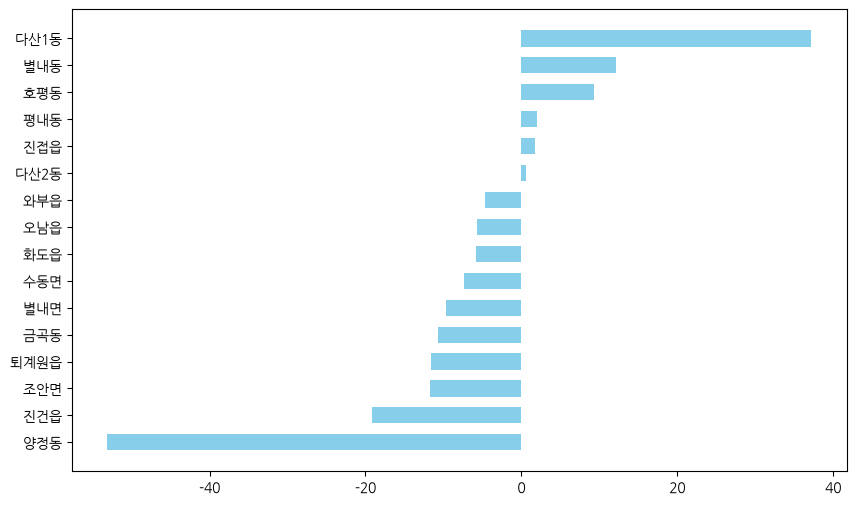

In [46]:
# 증감률 기준 오름차순 정렬
df_sorted = df_merged.sort_values(by='5개년_인구증감률(%)', ascending=True)

# 3. 가로 막대그래프 생성
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(df_sorted['행정구역'], df_sorted['5개년_인구증감률(%)'], color='skyblue', height=0.6)

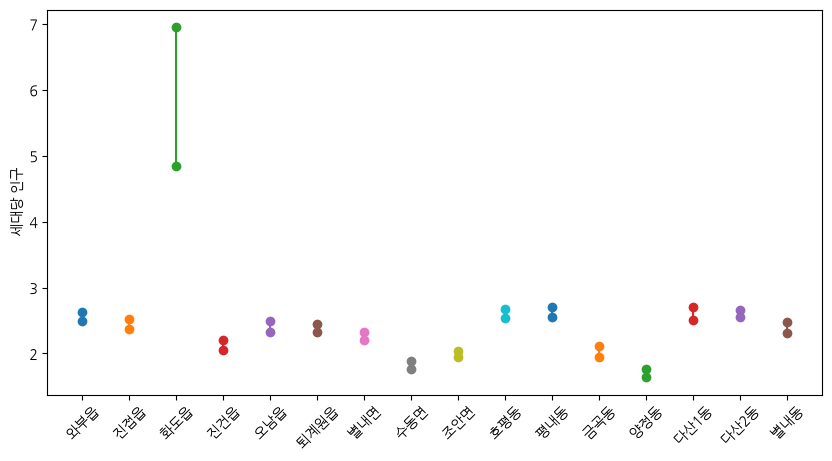

In [47]:
plt.figure(figsize=(10, 5))

for i, row in df_merged.iterrows():
    plt.plot(
        [row['행정구역'], row['행정구역']],
        [row['2020년_세대당 인구'], row['2025년_세대당 인구']],
        marker='o'
    )

plt.xticks(rotation=45)
plt.ylabel('세대당 인구')
plt.show()

##### 가구 축소의 원인을 찾아볼까 
- 외곽 지역(양정,수동,조안 등) : 고령화 및 독거노인 증가로 감소
- 신도시(다산, 별내 등) : 1-2 청년 혹은 신혼부부 유입으로 인한 감소 

In [48]:
# 1. 2025년 기준 유소년(0~9세) 확실하게 계산
df_merged['유소년비율'] = (df_merged['2025년_계_0~9세'] / df_merged['2025년_총인구수']) * 100

# (2) 청년·신혼 비율 (20~39세 = 20대 + 30대)
df_merged['청년신혼비율'] = ((df_merged['2025년_계_20~29세'] + df_merged['2025년_계_30~39세']) / df_merged['2025년_총인구수']) * 100


senior_2025 = ['2025년_계_70~79세', '2025년_계_80~89세', '2025년_계_90~99세', '2025년_계_100세 이상']
df_merged['고령비율'] = (df_merged[senior_2025].sum(axis=1) / df_merged['2025년_총인구수']) * 100


# 보기 편하게 소수점 둘째 자리로 반올림
df_merged['유소년비율'] = df_merged['유소년비율'].round(2)
df_merged['청년신혼비율'] = df_merged['청년신혼비율'].round(2)
df_merged['고령비율'] = df_merged['고령비율'].round(2)

In [49]:
# 1. 2025년 기준 가구 규모 및 연령 비율 결합 테이블 생성
df_hh_age = pd.DataFrame({
    '행정구역': df_merged['행정구역'],
    '유소년(%)': df_merged['유소년비율'],
    '청년신혼(%)': df_merged['청년신혼비율'],
    '고령(%)': df_merged['고령비율'],
    
})

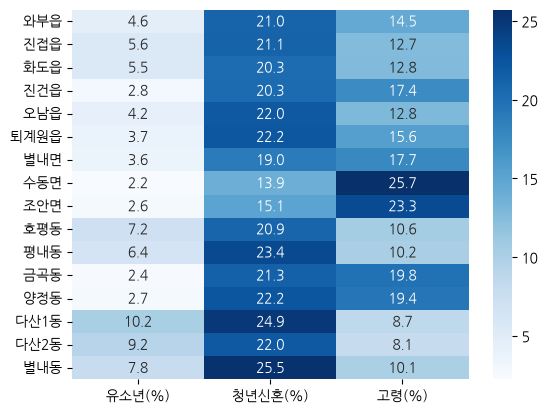

In [50]:
data = df_hh_age.set_index('행정구역')

sb.heatmap(data, annot=True, fmt='.1f', cmap='Blues')

plt.xlabel('')
plt.ylabel('')
plt.show()

#### 기준 근거
1. 초고령 / 복지취약형 (고령비율 15% 이상 또는 세대 당 인구 2.0명 미만)
2. 신도심 / 영유아성장형(유소년 비율 8.5% 이상)
3. 기존도심( 위 두 군데 속하지 않는 나머지)

## 4. 데이터 기반 남양주시 3대 생활권 유형화
히트맵을 통해 확인된 연령 구조와 세대당 인구수를 바탕으로, 16개 읍·면·동을 행정 목적에 맞는 3개 정책 대상군으로 분류합니다.

- **신도심 / 영유아·신혼 성장형:** 유소년(0~9세) 비율이 높고 청년층이 유입되는 지역 (다산1·2동, 별내동 등)
- **초고령 / 농촌·복지 취약형:** 고령층(70세+) 비율이 15% 이상이거나 세대당 인구가 1명대인 지역 (조안면, 수동면, 양정동 등)
- **기존도심 / 학령기·정주형:** 10대 학령기 자녀와 40~50대 중심의 안정적 주거 지역 (평내동, 진접읍, 와부읍 등)

In [51]:
# 2. 기본값을 '기존도심/학령기정주형'으로 지정
df_merged['지역_유형'] = '기존도심/학령기정주형'

# 3. 조건에 맞춰 유형 변경 (간단한 이름: 고령비율, 유소년비율 사용)
# (1) 초고령 취약형: 고령비율 15% 이상이거나 세대당 인구가 2명 미만
df_merged.loc[(df_merged['고령비율'] >= 15.0) | (df_merged['2025년_세대당 인구'] < 2.0), '지역_유형'] = '초고령/복지취약형'

# (2) 신도심 성장형: 유소년비율 8.5% 이상
df_merged.loc[df_merged['유소년비율'] >= 8.5, '지역_유형'] = '신도심/영유아성장형'

# 4. 결과 확인
display(df_merged[['행정구역', '지역_유형', '유소년비율', '고령비율', '2025년_세대당 인구']])

,행정구역,지역_유형,유소년비율,고령비율,2025년_세대당 인구
0,와부읍,기존도심/학령기정주형,4.61,14.48,2.50
1,진접읍,기존도심/학령기정주형,5.60,12.65,2.37
2,화도읍,기존도심/학령기정주형,5.55,12.77,6.95
3,진건읍,초고령/복지취약형,2.76,17.45,2.06
4,오남읍,기존도심/학령기정주형,4.20,12.81,2.33
5,퇴계원읍,초고령/복지취약형,3.74,15.59,2.32
6,별내면,초고령/복지취약형,3.59,17.72,2.20
7,수동면,초고령/복지취약형,2.23,25.71,1.77
8,조안면,초고령/복지취약형,2.62,23.31,1.94
9,호평동,기존도심/학령기정주형,7.18,10.61,2.54


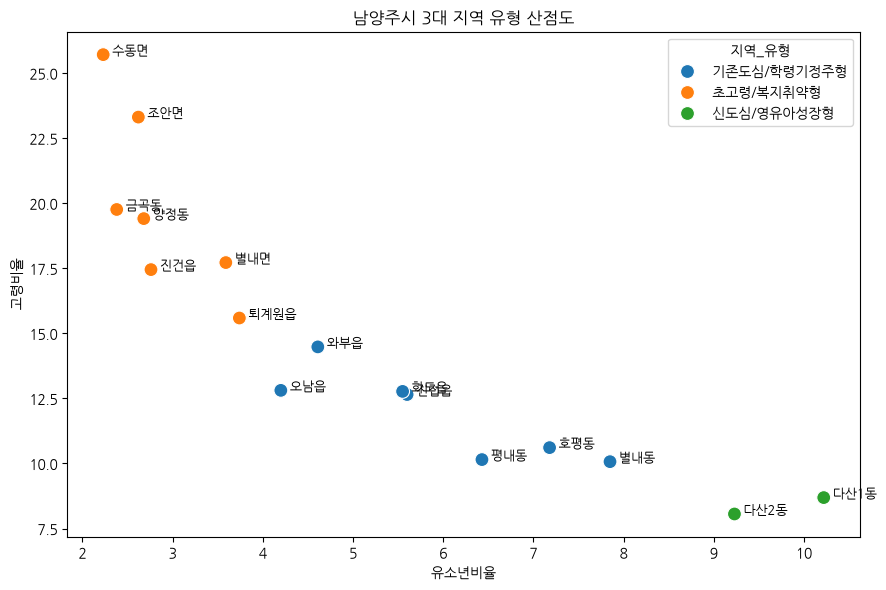

In [52]:
# 1. 점 찍기 (X: 유소년, Y: 고령, 색상: 지역_유형)
plt.figure(figsize=(9, 6))
sb.scatterplot(data=df_merged, x='유소년비율', y='고령비율', hue='지역_유형', s=100)

# 2. 점 옆에 동 이름 달기
for _, row in df_merged.iterrows():
    plt.text(row['유소년비율'] + 0.1, row['고령비율'], row['행정구역'], fontsize=9)

# 3. 제목 및 출력
plt.title('남양주시 3대 지역 유형 산점도')
plt.tight_layout()
plt.show()

#### 경기도 남양주시_어린이집 및 노인의료복지시설 읍면동별 개소수
- 인프라 파악을 위해 공공데이터 이용

https://www.data.go.kr/data/15160020/fileData.do

In [53]:
# 1. 파일 불러오기 및 기본 정제
df_infra_raw = pd.read_csv('data/어린이집 및 노인의료복지시설 읍면동별 수.csv', encoding='utf-8')
df_infra_raw['읍면동'] = df_infra_raw['읍면동'].str.strip().replace({'퇴계원면': '퇴계원읍'})

# 2. 피벗 대신 조건으로 따로 쪼개기 (단순 필터링)
df_kids = df_infra_raw[df_infra_raw['시설구분'] == '어린이집'][['읍면동', '개소수']].rename(columns={'읍면동': '행정구역', '개소수': '어린이집'})
df_senior = df_infra_raw[df_infra_raw['시설구분'] == '노인의료복지시설'][['읍면동', '개소수']].rename(columns={'읍면동': '행정구역', '개소수': '노인의료복지시설'})

# 3. 기존 df_merged에 하나씩 붙이기 (merge 2번)
df_supply = pd.merge(df_merged, df_kids, on='행정구역', how='left').fillna({'어린이집': 0})
df_supply = pd.merge(df_supply, df_senior, on='행정구역', how='left').fillna({'노인의료복지시설': 0})

# 확인
display(df_supply[['행정구역', '어린이집', '노인의료복지시설']])

,행정구역,어린이집,노인의료복지시설
0,와부읍,30,14.0
1,진접읍,46,35.0
2,화도읍,64,41.0
3,진건읍,7,4.0
4,오남읍,22,24.0
5,퇴계원읍,11,2.0
6,별내면,13,5.0
7,수동면,2,15.0
8,조안면,2,0.0
9,호평동,34,13.0


In [56]:
# # 1. 70세 이상 고령 인구수 계산 (지표 분모용)
# senior_pop = (df_supply['2025년_계_70~79세'] + df_supply['2025년_계_80~89세'] + 
#               df_supply['2025년_계_90~99세'] + df_supply['2025년_계_100세 이상'])

# # 2. 핵심 수급 지표 2개 생성 (1,000명당 시설 개수)
# # (1) 유소년 1,000명당 어린이집 개수
# df_supply['유소년_1000명당_어린이집'] = round((df_supply['어린이집'] / df_supply['2025년_계_0~9세']) * 1000, 2)

# # (2) 고령자 1,000명당 노인의료시설 개수
# df_supply['고령자_1000명당_노인시설'] = round((df_supply['노인의료복지시설'] / senior_pop) * 1000, 2)

# # 시설이 없거나 인구가 0인 경우 발생할 수 있는 결측치(NaN) 0으로 채우기
# df_supply['유소년_1000명당_어린이집'] = df_supply['유소년_1000명당_어린이집'].fillna(0)
# df_supply['고령자_1000명당_노인시설'] = df_supply['고령자_1000명당_노인시설'].fillna(0)

In [ ]:
# 1. 70세 이상 고령 인구 계산
senior_pop = (df_supply['2025년_계_70~79세'] + df_supply['2025년_계_80~89세'] + 
              df_supply['2025년_계_90~99세'] + df_supply['2025년_계_100세 이상'])

# 2. 필요한 핵심 컬럼만 골라 새 데이터프레임으로 구성
df_gap_analysis = pd.DataFrame({
    '행정구역': df_supply['행정구역'],
    '지역_유형': df_supply['지역_유형'],
    '유소년인구': df_supply['2025년_계_0~9세'],
    '어린이집개소수': df_supply['어린이집'],
    '유소년_1000명당_어린이집': round((df_supply['어린이집'] / df_supply['2025년_계_0~9세']) * 1000, 2),
    '고령인구': senior_pop,
    '노인시설개소수': df_supply['노인의료복지시설'],
    '고령자_1000명당_노인시설': round((df_supply['노인의료복지시설'] / senior_pop) * 1000, 2)
})

df_gap_analysis

,행정구역,지역_유형,유소년인구,어린이집개소수,유소년_1000명당_어린이집,고령인구,노인시설개소수,고령자_1000명당_노인시설
0,와부읍,기존도심/학령기정주형,2744.0,30,10.93,8627.0,14.0,1.62
1,진접읍,기존도심/학령기정주형,5311.0,46,8.66,11990.0,35.0,2.92
2,화도읍,기존도심/학령기정주형,6194.0,64,10.33,14254.0,41.0,2.88
3,진건읍,초고령/복지취약형,544.0,7,12.87,3434.0,4.0,1.16
4,오남읍,기존도심/학령기정주형,2125.0,22,10.35,6475.0,24.0,3.71
5,퇴계원읍,초고령/복지취약형,985.0,11,11.17,4104.0,2.0,0.49
6,별내면,초고령/복지취약형,641.0,13,20.28,3164.0,5.0,1.58
7,수동면,초고령/복지취약형,187.0,2,10.70,2160.0,15.0,6.94
8,조안면,초고령/복지취약형,97.0,2,20.62,863.0,0.0,0.00
9,호평동,기존도심/학령기정주형,3989.0,34,8.52,5900.0,13.0,2.20


findfont: Failed to find font weight bold, now using 600.


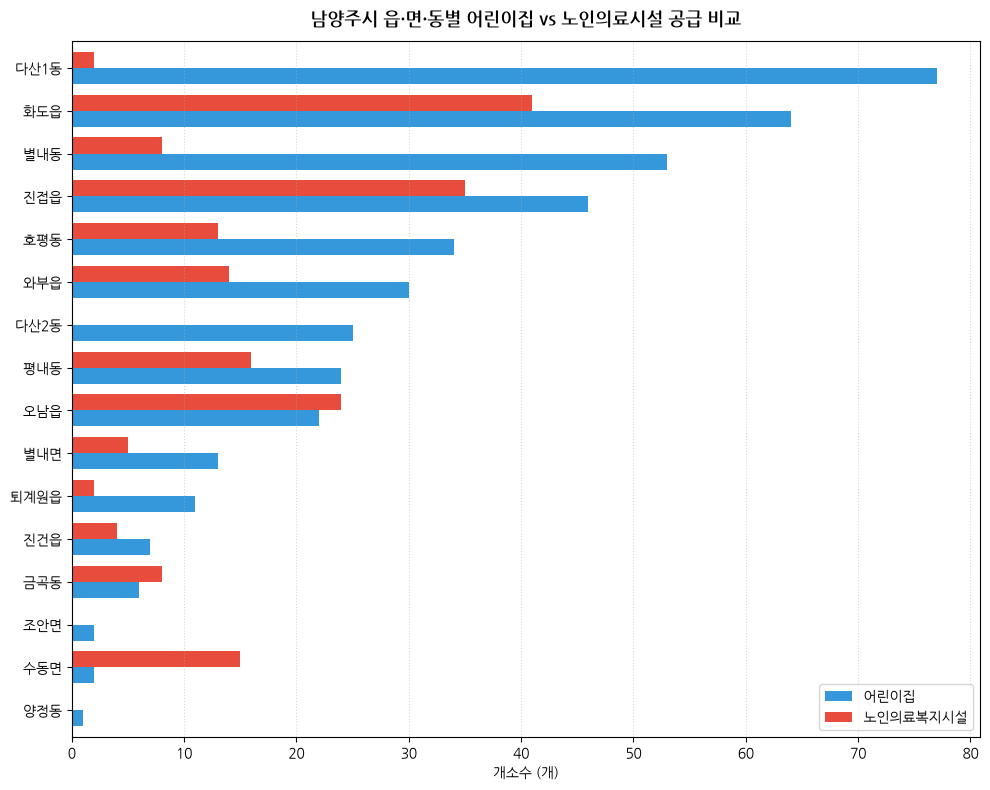

In [60]:
# 1. 어린이집 개소수 기준 내림차순 정렬
df_plot = df_gap_analysis.set_index('행정구역')[['어린이집개소수', '노인시설개소수']].sort_values(by='어린이집개소수', ascending=True)

# 2. 가로 막대그래프 플롯
fig, ax = plt.subplots(figsize=(10, 8))
df_plot.plot(kind='barh', ax=ax, color=['#3498db', '#e74c3c'], width=0.75)

plt.title('남양주시 읍·면·동별 어린이집 vs 노인의료시설 공급 비교', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('개소수 (개)')
plt.ylabel('')
plt.legend(['어린이집', '노인의료복지시설'], loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [61]:
# 신도심/영유아성장형 중 아이 천명당 어린이집이 적은 순
df_gap_analysis[df_gap_analysis['지역_유형'] == '신도심/영유아성장형'].sort_values('유소년_1000명당_어린이집')

,행정구역,지역_유형,유소년인구,어린이집개소수,유소년_1000명당_어린이집,고령인구,노인시설개소수,고령자_1000명당_노인시설
13,다산1동,신도심/영유아성장형,10811.0,77,7.12,9187.0,2.0,0.22
14,다산2동,신도심/영유아성장형,3371.0,25,7.42,2942.0,0.0,0.00


In [62]:
# 노인시설이 0개인 동 추출
df_gap_analysis[df_gap_analysis['노인시설개소수'] == 0][['행정구역', '지역_유형', '고령인구', '노인시설개소수']]

,행정구역,지역_유형,고령인구,노인시설개소수
8,조안면,초고령/복지취약형,863.0,0.0
12,양정동,초고령/복지취약형,420.0,0.0
14,다산2동,신도심/영유아성장형,2942.0,0.0


2025년 기준 남양주시 16개 읍·면·동의 인구 구조(총인구, 세대원수, 유소년/고령 비율)와 필수 생활 인프라(어린이집, 노인시설 등)의 공간적 수급 불균형을 분석하여 맞춤형 정책 방향 도출

---

##### 1. 3대 생활권 유형화 및 핵심 특징

| 권역 유형 | 대상 행정구역 | 인구 특성 요약 | 
| :--- | :--- | :--- |
| **🚀 신도심 / 영유아성장형** | 다산1·2동, 별내동 | • 3040 청장년층 및 영유아 비율 최상위<br>• 지속적인 인구 유입 및 대규모 주거단지 형성 | 
| **🏡 기존도심 / 학령기정주형** | 화도읍, 진접읍, 와부읍, 평내·호평동 등 | • 남양주 전통의 주거 중심지<br>• 전 연령층이 고르게 분포, 안정적 정주 환경 | 
| **🌾 초고령 / 복지취약형** | 수동면, 조안면, 양정동, 금곡동 | • 65세 이상 고령 비율 급증 (초고령사회 진입)<br>• 1~2인 가구 비중 높음, 인구 정체·감소세 |

---

##### 2. 주요 발견점

1. **인구 구조의 뚜렷한 공간 양극화**
   * 다산신도시 및 별내지구 중심의 **영유아·청장년층 집중 현상**과 외곽 면 단위(수동·조안 등) 및 구도심(양정·금곡 등)의 **급격한 고령화**가 뚜렷하게 대비됩니다.
2. **시설 0개 지역의 복지 사각지대**
   * 고령 인구 비율이 높은 일부 지역(조안면, 양정동 등)은 고정형 노인복지시설의 접근성이 취약하여 동일한 행정서비스 혜택을 받기 어려운 구조입니다.
3. **영유아 인구 급증 대비 돌봄 체감도 격차**
   * 다산동 일대는 인구 유입 속도가 빨라 어린이집 1개소당 유소년 수가 매우 높아 추가적인 보육 인프라 확충이 지속적으로 요구됩니다.

---

